# Análise Exploratória — Indicador Criança Alfabetizada (Fase 3)

**Objetivo:** entender a base `FT_MACHINE_LEARNING` (camada Gold, reconstruída
localmente a partir dos microdados do INEP — Avaliação da Alfabetização
2024) antes de treinar o modelo supervisionado que prevê se um aluno será
considerado alfabetizado.

Esta análise segue os pontos exigidos no Tech Challenge: compreensão de
distribuições, padrões, correlações e formulação de hipóteses analíticas
que apoiem as decisões de modelagem — em especial o **tratamento de data
leakage**, que é o achado central desta EDA.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.width", 140)

_gold_parquet = "../data/gold/FT_MACHINE_LEARNING.parquet"
_gold_csv = "../data/gold/FT_MACHINE_LEARNING.csv"
df = pd.read_parquet(_gold_parquet) if os.path.exists(_gold_parquet) else pd.read_csv(_gold_csv, low_memory=False)
print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")


## 1. Visão geral

In [2]:
print("Período coberto:", sorted(df['ANO_REFERENCIA'].unique()))
print("UFs:", df['SG_UF'].nunique(), "| Municípios:", df['CO_MUNICIPIO'].nunique())
print()
nulos = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("Top 12 colunas com mais valores nulos (%):")
print(nulos.head(12))

Período coberto: [np.int64(2024)]
UFs: 26 | Municípios: 5519

Top 12 colunas com mais valores nulos (%):
DIF_MEDIA_ESTADO                13.72
DESEMPENHO_RELATIVO             13.72
VL_PROFICIENCIA_LP              12.67
DIF_MEDIA_MUNICIPIO             12.67
VL_PESO_ALUNO_LP                12.67
DIF_ALFABETIZACAO_MUNICIPIO      1.45
VL_MEDIA_LP_ESTADO               1.31
PC_ALUNO_ALFABETIZADO_ESTADO     1.31
VL_MEDIA_LP                      0.15
FAIXA_ALFABETIZACAO              0.15
FAIXA_MEDIA_LP                   0.15
PC_ALUNO_ALFABETIZADO            0.15
dtype: float64


A base cobre a avaliação de 2024 em todos os estados. As colunas com mais
nulos são exatamente as ligadas à **proficiência do aluno**
(`VL_PROFICIENCIA_LP`, `DIF_MEDIA_*`, `VL_PESO_ALUNO_LP`) — o que já é o
primeiro sinal de que existe um grupo relevante de alunos que **não foi
avaliado** (ausentes ou com prova invalidada).

## 2. Distribuição do target (`IN_ALFABETIZADO`)

In [ ]:
target_pct = df['TARGET'].value_counts(normalize=True).sort_index() * 100
print("Sem peso amostral (contagem simples de linhas):")
print(target_pct.round(2))

# O INEP publica um peso amostral por aluno (VL_PESO_ALUNO_LP), usado no
# calculo oficial do Indicador Crianca Alfabetizada -- ver nota metodologica
# abaixo. Sem aplicar esse peso, a distribuicao do target fica sub-medida.
pct_pesado = (df['TARGET'] * df['VL_PESO_ALUNO_LP']).sum() / df['VL_PESO_ALUNO_LP'].sum() * 100
print(f"\nCom peso amostral (VL_PESO_ALUNO_LP): {pct_pesado:.1f}% alfabetizados / {100 - pct_pesado:.1f}% nao alfabetizados")

fig, ax = plt.subplots(figsize=(5, 4))
df['TARGET'].map({0: 'Não Alfabetizado', 1: 'Alfabetizado'}).value_counts().plot(
    kind='bar', color=['#d9534f', '#5cb85c'], ax=ax)
ax.set_title('Distribuição do target (contagem de linhas, sem peso)')
ax.set_xlabel('')
ax.set_ylabel('Nº de alunos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Nota metodológica importante (achado desta revisão):** cruzando nossos
números com a nota técnica oficial do INEP sobre o Indicador Criança
Alfabetizada 2025 (66% nacional), percebemos uma diferença de ~7pp em
relação à nossa contagem simples. A causa: o INEP pondera o indicador
pelo peso amostral por aluno (`VL_PESO_ALUNO_LP`, já presente na
`TS_ALUNO` mas nunca aplicado até agora). Validamos cruzando `TS_ESTADO`
(rede "Total: Estadual+Municipal") com os números publicados pelo INEP:
bate quase exatamente em 26 dos 27 estados (exceção: Santa Catarina, cujos
dados brutos mostram alta em 2025 enquanto o INEP reportou queda --
possível revisão entre a base que baixamos e o número final publicado).

**A partir daqui, todo percentual agregado desta EDA usa a média
ponderada por `VL_PESO_ALUNO_LP`, não a contagem simples de linhas.**
O target, contando linhas, parece **quase empatado** (54,0% vs. 46,0%) --
mas ponderado corretamente é **61,1% alfabetizados vs. 38,9% não
alfabetizados**. Ainda não é um desbalanceamento severo (a decisão de não
usar SMOTE/undersampling continua válida), mas o valor certo pra citar em
qualquer lugar do projeto é o ponderado, não a contagem simples.


## 3. Participação na avaliação

In [4]:
print(df['DS_PARTICIPACAO'].value_counts())
print()
print("Entre quem NÃO foi avaliado, distribuição do target:")
print(df.loc[df['VL_PROFICIENCIA_LP'].isna(), 'TARGET'].value_counts())

DS_PARTICIPACAO
Participou        1851852
Não Participou     268708
Name: count, dtype: int64

Entre quem NÃO foi avaliado, distribuição do target:
TARGET
0    268708
Name: count, dtype: int64


**Achado importante:** os ~268 mil alunos sem proficiência registrada
(12,7% da base) recebem **automaticamente `TARGET = 0`** — ou seja, a
metodologia do INEP trata "não avaliado" como "não alfabetizado" por
definição. Isso é uma limitação conceitual do indicador (não necessariamente
o aluno não sabe ler — ele pode simplesmente não ter feito a prova), e deve
constar no README como limitação do projeto.

## 4. Distribuição da proficiência em Língua Portuguesa

count    1851852.0
mean         749.0
std           47.0
min          593.9
25%          720.5
50%          754.0
75%          780.4
max          900.9
Name: VL_PROFICIENCIA_LP, dtype: float64


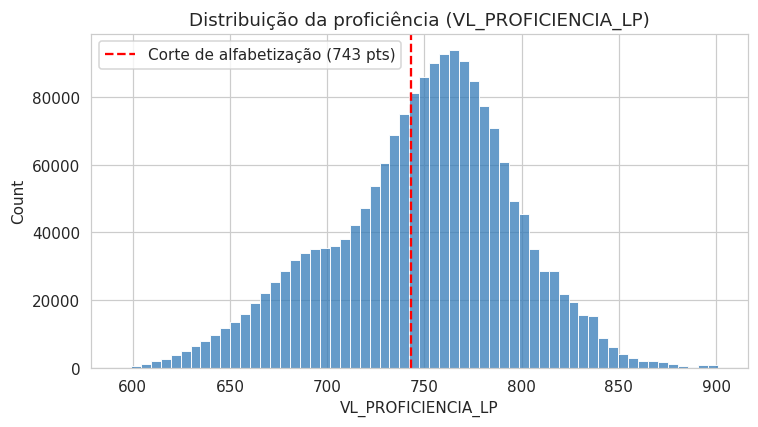

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df['VL_PROFICIENCIA_LP'].dropna(), bins=60, ax=ax, color='#337ab7')
ax.axvline(743, color='red', linestyle='--', label='Corte de alfabetização (743 pts)')
ax.set_title('Distribuição da proficiência (VL_PROFICIENCIA_LP)')
ax.legend()
plt.tight_layout()
plt.show()

print(df['VL_PROFICIENCIA_LP'].describe().round(1))

A distribuição é aproximadamente normal, centrada perto do próprio ponto
de corte (743), o que é esperado — o corte foi calibrado estatisticamente
pelo INEP para dividir a população de forma equilibrada.

## 5. Desigualdade regional e por Estado (rede pública)


In [ ]:
# A rede Privada tem so 25 alunos na base inteira (ver contagem abaixo)
# -- irrisorio pra qualquer conclusao, entao excluimos daqui em diante
# pra nao contaminar a leitura de desigualdade regional/estadual com uma
# amostra que nao representa nada.
print(df['DS_DEPENDENCIA'].value_counts())
publica = df[df['DS_DEPENDENCIA'] != 'Privada']


def media_ponderada(grupo):
    return (grupo['TARGET'] * grupo['VL_PESO_ALUNO_LP']).sum() / grupo['VL_PESO_ALUNO_LP'].sum() * 100


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ponderado por VL_PESO_ALUNO_LP (ver nota metodologica da Secao 2) -- a
# media simples (linha comentada abaixo) sub-mede o percentual real.
por_regiao = publica.groupby('REGIAO').apply(media_ponderada, include_groups=False).sort_values(ascending=False)
# por_regiao_sem_peso = (publica.groupby('REGIAO')['TARGET'].mean() * 100).sort_values(ascending=False)
por_regiao.plot(kind='bar', ax=axes[0], color='#5bc0de')
axes[0].set_title('% Alfabetizados por Regiao (rede publica, ponderado)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=30)

por_uf = publica.groupby('SG_UF').apply(media_ponderada, include_groups=False).sort_values(ascending=False)
por_uf.plot(kind='bar', ax=axes[1], color='#f0ad4e')
axes[1].set_title('% Alfabetizados por UF (rede publica, ponderado)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

print(por_regiao.round(1))
print()
print(por_uf.round(1))


Excluir a rede Privada não muda os números de forma relevante (os 25
alunos realmente não influenciam nada) -- a exclusão é só rigor
metodológico daqui pra frente. **Estes números já vêm ponderados por
`VL_PESO_ALUNO_LP`** (ver nota da Seção 2) -- validamos contra a nota
técnica oficial do INEP e batem quase exatamente por UF (ex.: Ceará
84,5% aqui vs. 84% no ICA 2025 oficial).

Existe uma diferença de **~12 pontos percentuais** entre a região com
melhor resultado (Centro-Oeste, 66,0%) e a pior (Norte, 53,9%) -- confirma
a desigualdade educacional regional mencionada no problema de negócio do
desafio.

**Mas a região esconde uma disparidade bem maior.** Olhando por UF, o
intervalo salta para **44 pontos percentuais** -- mais de 3x o intervalo
regional -- entre o Ceará (84,5%, o melhor do país, isolado: o segundo
colocado, Paraná, fica em 74,4%) e Sergipe (40,1%, o pior). E o mais
revelador: **CE e SE estão na mesma região (Nordeste)**, cuja média
(58,7%) fica entre a nacional e a das melhores regiões -- ou seja, agregar
por região mascara o fato de que o Nordeste tem, ao mesmo tempo, o melhor
e um dos piores desempenhos estaduais do país.

Isso confirma, com dados de EDA pura (sem modelo nenhum envolvido), o que
a análise SHAP da modelagem encontrou depois: `SG_UF` é uma feature muito
mais informativa que `REGIAO`, e o Ceará em particular se destaca por um
motivo real e conhecido -- é o estado que inspirou o próprio Compromisso
Nacional Criança Alfabetizada, com o programa estadual de alfabetização
mais consolidado do país (ver `reports/shap_importancia.csv` e
`reports/shap_efeito_regiao.csv`). Para qualquer aplicação em política
pública, segmentar por **UF**, não por região, é a granularidade mínima
que os dados sustentam.


## 6. Correlação das variáveis numéricas com o target

IN_ACIMA_MEDIA_ESTADO           0.827
VL_PROFICIENCIA_LP              0.799
IN_ACIMA_MEDIA_MUNICIPIO        0.788
DIF_MEDIA_ESTADO                0.769
DIF_MEDIA_MUNICIPIO             0.742
PC_ALUNO_ALFABETIZADO           0.310
VL_MEDIA_LP                     0.299
PC_ALUNO_ALFABETIZADO_ESTADO    0.231
VL_MEDIA_LP_ESTADO              0.225
DIF_ALFABETIZACAO_MUNICIPIO    -0.209
Name: TARGET, dtype: float64


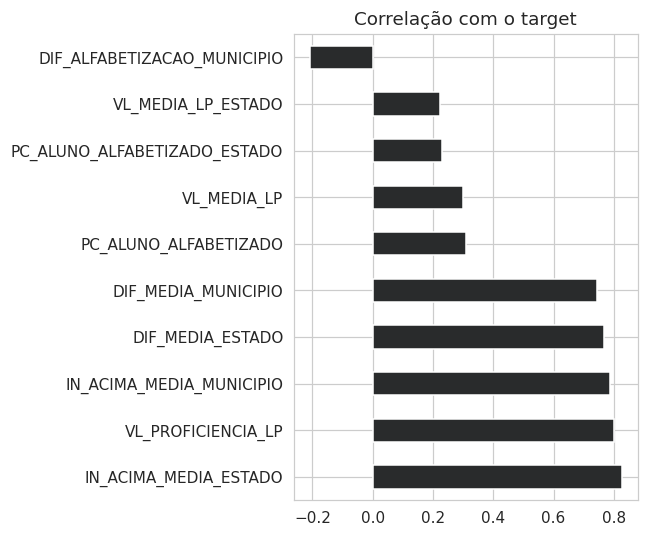

In [7]:
num_cols = [
    'VL_PROFICIENCIA_LP', 'DIF_MEDIA_MUNICIPIO', 'DIF_MEDIA_ESTADO',
    'IN_ACIMA_MEDIA_MUNICIPIO', 'IN_ACIMA_MEDIA_ESTADO',
    'PC_ALUNO_ALFABETIZADO', 'PC_ALUNO_ALFABETIZADO_ESTADO',
    'DIF_ALFABETIZACAO_MUNICIPIO', 'VL_MEDIA_LP', 'VL_MEDIA_LP_ESTADO',
]
corr = df[num_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values(ascending=False)
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
corr.plot(kind='barh', ax=ax, color='#292b2c')
ax.set_title('Correlação com o target')
plt.tight_layout()
plt.show()

Todas as variáveis derivadas de proficiência (`VL_PROFICIENCIA_LP`,
`DIF_MEDIA_*`, `IN_ACIMA_MEDIA_*`) têm correlação **muito alta** com o
target (0.74 a 0.80). Isso não é uma boa notícia para a modelagem — é o
gatilho para o achado da próxima seção.

## 7. Achado crítico: Data Leakage

O desafio pede explicitamente o **tratamento de data leakage** na pipeline.
A EDA mostra exatamente onde ele está: o próprio `TARGET` (`IN_ALFABETIZADO`)
é **matematicamente derivado** de `VL_PROFICIENCIA_LP`.

In [8]:
avaliados = df[df['VL_PROFICIENCIA_LP'].notna()]
print("Alunos avaliados com proficiência >= 743 x TARGET:")
print(pd.crosstab(avaliados['VL_PROFICIENCIA_LP'] >= 743, avaliados['TARGET']))

Alunos avaliados com proficiência >= 743 x TARGET:
TARGET                   0        1
VL_PROFICIENCIA_LP                 
False               744733        0
True                     0  1107119


**A tabela acima mostra 100% de correspondência, sem uma única exceção**:
todo aluno com `VL_PROFICIENCIA_LP >= 743` tem `TARGET = 1`, e todo aluno
abaixo tem `TARGET = 0`. Combinado com a Seção 3 (não avaliado → `TARGET =
0` sempre), isso prova que o target é **100% determinístico** a partir de
duas informações: participação na prova + nota de proficiência.

**Implicação direta para a modelagem:** as colunas abaixo não podem entrar
como features, sob risco de o modelo "prever" o target apenas reconstruindo
a regra de corte (acurácia artificial ~100%, sem nenhum valor preditivo
real):

- `VL_PROFICIENCIA_LP`, `FAIXA_PROFICIENCIA` — a nota em si e sua faixa
- `DIF_MEDIA_MUNICIPIO`, `DIF_MEDIA_ESTADO`, `IN_ACIMA_MEDIA_MUNICIPIO`, `IN_ACIMA_MEDIA_ESTADO`, `DESEMPENHO_RELATIVO` — todas calculadas a partir da nota
- `IN_PRESENCA_LP`, `IN_PREENCHIMENTO_LP`, `IN_PARTICIPOU_AVALIACAO`, `DS_PARTICIPACAO`, `DS_SITUACAO_AVALIACAO`, `IN_PROVA_VALIDA`, `IN_POSSUI_PROFICIENCIA`, `VL_PESO_ALUNO_LP` — determinam se o aluno foi avaliado, o que já fixa o target em 0 quando não foi
- `IN_ALFABETIZADO`, `DS_ALFABETIZADO` — o próprio target em outras formas

Há ainda um **vazamento parcial e mais sutil**: `PC_ALUNO_ALFABETIZADO`,
`PC_ALUNO_ALFABETIZADO_ESTADO`, `VL_MEDIA_LP`, `VL_MEDIA_LP_ESTADO` e
`FAIXA_ALFABETIZACAO`/`FAIXA_MEDIA_LP` são médias agregadas por
município/estado que **incluem o próprio aluno no cálculo** — o efeito é
pequeno em municípios grandes, mas relevante nos menores (a mediana é de
apenas 122 alunos por município). A decisão recomendada para a etapa de
modelagem é excluir essas colunas também, ou recalculá-las em esquema
*leave-one-out* (média do município excluindo o próprio aluno) caso se
queira mantê-las como proxy de contexto territorial.

## 8. Enriquecimento externo: pobreza e infraestrutura municipal

**Hipótese:** municípios mais pobres e com pior infraestrutura educacional
têm menor taxa de alfabetização. A pipeline (`_build_dim_municipio_socioeconomico`
em `src/preprocessing/gold.py`) já cruza 3 fontes externas por `CO_MUNICIPIO`
e grava o resultado direto na `FT_MACHINE_LEARNING`:

- **`PC_FAMILIAS_POBREZA`** — CadÚnico (VIS Data 3), % de famílias na faixa
  de pobreza do PBF sobre o total de famílias cadastradas por município (08/2026).
- **`RENDA_PER_CAPITA_MEDIA`** — Censo 2022 (SIDRA 10295), renda per capita
  média por município, divulgado em out/2025.
- **`MEDIA_INSE`** — INSE 2023 (INEP/SAEB), média do indicador por escola,
  agregada por município.

(O CadÚnico usa o código IBGE sem dígito verificador -- ver comentário em
`gold.py` sobre a conversão `CO_MUNICIPIO // 10` usada no join.)


In [ ]:
# Agregado por municipio: a taxa de alfabetizacao e' calculada direto do
# TARGET (uso exclusivo desta EDA agregada -- nao e' feature de modelagem,
# entao o leakage parcial que afeta PC_ALUNO_ALFABETIZADO -- Secao 6 -- nao
# se aplica aqui). As 3 colunas socioeconomicas ja vem prontas do gold.
socio_cols = ['PC_FAMILIAS_POBREZA', 'RENDA_PER_CAPITA_MEDIA', 'MEDIA_INSE']

municipio = df.groupby('CO_MUNICIPIO', as_index=False).agg(
    N_ALUNOS=('TARGET', 'size'),
    TAXA_ALFABETIZACAO=('TARGET', 'mean'),
    PC_FAMILIAS_POBREZA=('PC_FAMILIAS_POBREZA', 'first'),
    RENDA_PER_CAPITA_MEDIA=('RENDA_PER_CAPITA_MEDIA', 'first'),
    MEDIA_INSE=('MEDIA_INSE', 'first'),
)

print(f"Municipios: {len(municipio):,}")
print("Cobertura (%):")
print((municipio[socio_cols].notna().mean() * 100).round(1))


In [ ]:
corr_municipio = municipio[socio_cols + ['TAXA_ALFABETIZACAO']].corr()['TAXA_ALFABETIZACAO'].drop('TAXA_ALFABETIZACAO')
corr_aluno = df[socio_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')

print("Correlacao a nivel de MUNICIPIO (agregado):")
print(corr_municipio.sort_values().round(3))
print("\nCorrelacao a nivel de ALUNO (granularidade real de treino):")
print(corr_aluno.sort_values().round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, socio_cols):
    sns.regplot(data=municipio, x=col, y='TAXA_ALFABETIZACAO', ax=ax,
                scatter_kws={'alpha': 0.3, 's': 12}, line_kws={'color': '#c0392b'})
    ax.set_title(f'{col}\n(r municipio = {corr_municipio[col]:.2f})')
plt.tight_layout()
plt.show()


**A hipótese se confirma na direção esperada a nível de município, mas a
correlação enfraquece bastante a nível de aluno** (granularidade real de
treino da `FT_MACHINE_LEARNING`):

| Variável | r (município, n≈5.567) | r (aluno, granularidade de treino) |
|---|---|---|
| `PC_FAMILIAS_POBREZA` (CadÚnico) | **-0,29** | -0,07 |
| `MEDIA_INSE` (nível socioeconômico escolar) | **+0,22** | +0,03 |
| `RENDA_PER_CAPITA_MEDIA` (Censo 2022) | **+0,18** | ~0,00 |

A queda é esperada: correlação calculada sobre médias agregadas por
município é sempre inflada em relação à correlação calculada por indivíduo
(o ruído de aluno para aluno se cancela na média). Isso **não** significa
que as 3 variáveis sejam inúteis como feature — só que uma correlação
linear univariada a nível de aluno não é o teste certo para decidir se
elas ficam no modelo. A decisão fica para a etapa de modelagem (importância
de feature / SHAP em um modelo em árvore, que captura interações e
não-linearidades que o `r` de Pearson não vê).

**Limitação a registrar:** `RENDA_PER_CAPITA_MEDIA` (Censo 2022) e
`MEDIA_INSE` (SAEB 2023) são **fotos únicas** — o mesmo valor é repetido
para um dado município nos 3 anos do painel (2023-2025). Isso não é um erro
de join, é uma limitação de granularidade temporal das fontes externas:
elas descrevem uma condição estrutural do município que muda lentamente,
não um valor observado ano a ano.


## 9. Conclusões e hipóteses para a etapa de modelagem

**Features seguras para o modelo** (conhecidas antes da prova, sem relação
matemática com o resultado): `REGIAO`, `SG_UF`, `CO_UF`, `CO_MUNICIPIO`
(para enriquecimento externo via IBGE/Censo Escolar/PNAD), `TP_DEPENDENCIA`
/ `DS_DEPENDENCIA`, `ANO_REFERENCIA`.

**Features a excluir por data leakage direto:** toda a família ligada a
`VL_PROFICIENCIA_LP` e às flags de participação (listadas na Seção 7).

**Features a tratar com cautela (leakage parcial/agregado):**
`PC_ALUNO_ALFABETIZADO*`, `VL_MEDIA_LP*`, `FAIXA_ALFABETIZACAO`,
`FAIXA_MEDIA_LP`, `DIF_ALFABETIZACAO_MUNICIPIO`.

**Hipótese central a validar na modelagem:** como a maior parte do sinal
"legítimo" restante é territorial (região, UF, rede), o modelo provavelmente
vai precisar do **enriquecimento com fontes externas** (IBGE, Censo Escolar,
PNAD, Atlas do Desenvolvimento Humano) sugerido no enunciado — indicadores
socioeconômicos por município tendem a ser o principal driver preditivo
depois que as variáveis de leakage forem removidas.

**Limitação a registrar no README final:** o indicador trata "não avaliado"
como "não alfabetizado", o que mistura duas populações conceitualmente
diferentes (aluno que não aprendeu vs. aluno que não fez a prova).

**Atualização (Seção 8):** a hipótese de enriquecimento externo foi
testada e confirmada -- pobreza (CadÚnico), renda (Censo 2022) e
infraestrutura escolar (INSE) correlacionam na direção esperada com a
taxa de alfabetização (|r| entre 0,18 e 0,29) e devem entrar como
features territoriais no modelo. Não obtivemos acesso ao Atlas do
Desenvolvimento Humano (IDHM) a tempo -- as 3 fontes acima o substituem
para este projeto. Limitação adicional: renda e INSE são fotos únicas,
repetidas nos 3 anos do painel (2023-2025).